In [47]:
import numpy as np
import pandas as pd

In [48]:
df = pd.read_csv('/content/placement.csv')

In [49]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [50]:
df.shape

(100, 4)

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [52]:
# Steps

# 0. Preprocess + EDA + Feature Selection
# 1. Extract input and output cols
# 2. Scale the values
# 3. Train test split
# 4. Train the model
# 5. Evaluate the model/model selection
# 6. Deploy the model

**For preprocessing the data, we observed that column 0 is not very useful as it does not any conclusive data, so we can remove that column.**

In [53]:
df = df.iloc[:,1:]

In [54]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [55]:
import matplotlib.pyplot as plt

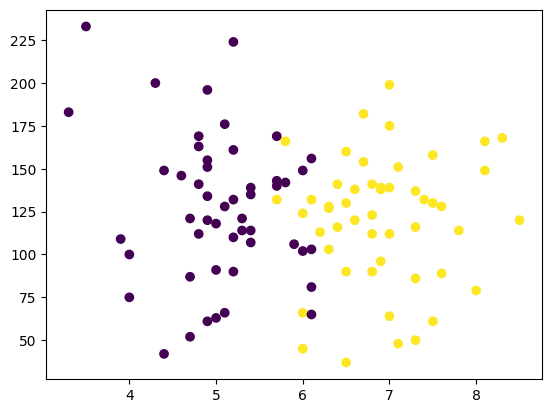

In [56]:
plt.scatter(df['cgpa'], df['iq'], c=df['placement'])

In [57]:
# "CGPA" and "IQ" are independent variables while "Placement" is dependent variable.
X = df.iloc[:, 0:2]
Y = df.iloc[:,-1]

In [58]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [59]:
Y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [60]:
# X is a 2D Tensor
X.shape


(100, 2)

In [61]:
# Y is a 1D Tensor
Y.shape

(100,)

**Train Test Split**

In [75]:
from sklearn.model_selection import train_test_split
# We use 10% data as test/validation data
X_train,X_test,Y_train,Y_test = train_test_split(X, Y, test_size=0.1)

In [76]:
X_test

,cgpa,iq
1,5.9,106.0
90,7.3,86.0
71,6.1,132.0
86,5.1,128.0
74,6.7,154.0
60,6.9,139.0
32,7.0,139.0
81,5.4,107.0
72,7.3,116.0
46,5.3,114.0


**Scaling of Data Set** (B/W [-1, 1])

In [77]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [78]:
X_train = scaler.fit_transform(X_train)

In [79]:
X_train

array([[-0.99361694,  0.41671615],
       [-0.99361694,  1.09290719],
       [ 1.1539701 , -1.78090474],
       [ 1.75529448, -1.08056402],
       [-2.28216916,  1.43100271],
       [-0.47819605,  0.36841679],
       [ 1.41168055, -0.83906722],
       [ 0.46674225, -0.81491754],
       [ 0.12312832, -0.5009717 ],
       [-1.33723087,  0.60991359],
       [-0.90771346,  1.74494855],
       [ 1.1539701 ,  0.32011743],
       [ 0.81035618,  0.34426711],
       [ 2.01300492,  1.06875751],
       [-1.68084479, -1.17716274],
       [-1.07952042, -1.73260538],
       [-0.47819605, -0.23532522],
       [ 1.84119796,  0.60991359],
       [ 0.98216314,  0.65821295],
       [ 0.46674225, -2.09485059],
       [-0.2204856 ,  1.09290719],
       [-0.82180998, -0.1387265 ],
       [-0.90771346,  0.65821295],
       [ 0.29493529,  0.07862063],
       [-1.42313435,  1.84154727],
       [ 0.7244527 , -0.81491754],
       [-1.68084479, -0.57342074],
       [-0.82180998, -1.4669589 ],
       [-0.73590649,

In [80]:
X_test = scaler.transform(X_test)

In [81]:
X_test

array([[-0.04867864, -0.42852266],
       [ 1.1539701 , -0.91151626],
       [ 0.12312832,  0.19936903],
       [-0.73590649,  0.10277031],
       [ 0.63854921,  0.73066199],
       [ 0.81035618,  0.36841679],
       [ 0.89625966,  0.36841679],
       [-0.47819605, -0.40437298],
       [ 1.1539701 , -0.18702586],
       [-0.56409953, -0.23532522]])

**Training the Model**

In [83]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()

In [92]:
# Model Training
clf.fit(X_train, Y_train)
print(clf.coef_)
print(clf.intercept_)

[[ 3.2230671  -0.13408731]]
[-0.08879919]


**Evaluate the Model**

In [96]:
Y_pred = clf.predict(X_test)

In [94]:
Y_test

,placement
1,0
90,1
71,1
86,0
74,1
60,1
32,1
81,0
72,1
46,0


In [97]:
from sklearn.metrics import accuracy_score
accuracy_score(Y_test, Y_pred)

1.0

<Axes: >

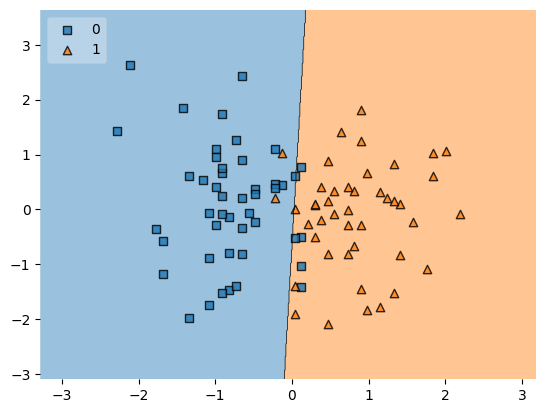

In [98]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X_train, Y_train.values, clf=clf, legend=2)

In [99]:
# Dumping of model to file
import pickle
pickle.dump(clf, open('model.pkl', 'wb'))